# Examen Práctico ISI
Autor: Melanie Buenaño

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

archivo = files.upload()

Saving real_estate_ecuador_200k.csv to real_estate_ecuador_200k.csv


In [8]:
df = pd.read_csv("real_estate_ecuador_200k.csv")

In [25]:
df.head()

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages,Costo_m2,Tipo
0,rento suite 75 metros sector republica del sal...,395.66,Pichincha,"Pichincha, Av. Portugal & Av República de El S...",1.0,2.0,65,1.0,6.087077,Suite
1,“rento departamento en sector la carolina”,773.69,Pichincha,"Pichincha, Catalina de Aldaz & Av. Portugal, Q...",2.0,2.0,88,1.0,8.791932,Departamento
2,se renta amplio departamento en el sector de l...,616.94,Pichincha,"Pichincha, Marcos Jofre, Quito, Ecuador",4.0,4.0,214,1.0,2.882897,Departamento
3,hermoso departamento de arriendo de oportunida...,286.69,Pichincha,"Pichincha, De la Prensa Y del Maestro, Quito, ...",2.0,2.0,98,1.0,2.925408,Departamento
4,"en renta departamento, conjunto divino niño",131.54,Pichincha,"Pichincha, Turubamaba, Ecuador",3.0,2.0,53,0.0,2.481887,Departamento


In [11]:
df.columns

Index(['Titulo', 'Precio', 'Provincia', 'Lugar', 'Num. dormitorios',
       'Num. banos', 'Area', 'Num. garages'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Titulo            200000 non-null  object 
 1   Precio            200000 non-null  float64
 2   Provincia         200000 non-null  object 
 3   Lugar             200000 non-null  object 
 4   Num. dormitorios  146845 non-null  float64
 5   Num. banos        165015 non-null  float64
 6   Area              200000 non-null  int64  
 7   Num. garages      142163 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 12.2+ MB


In [12]:
df.describe()

,Precio,Num. dormitorios,Num. banos,Area,Num. garages
count,200000.000000,146845.000000,165015.000000,200000.00000,142163.000000
mean,732.351461,2.504144,2.212377,579.01968,1.888691
std,870.573142,1.166590,1.193415,8915.40402,2.959052
min,7.220000,1.000000,1.000000,10.00000,0.000000
25%,371.770000,2.000000,1.000000,73.00000,1.000000
50%,510.490000,3.000000,2.000000,101.00000,1.000000
75%,728.642500,3.000000,3.000000,146.00000,2.000000
max,11062.330000,11.000000,11.000000,229852.00000,35.000000


In [20]:
# Eliminar filas duplicadas
df = df.drop_duplicates()

# Eliminar espacios al inicio y final de los textos
df["Provincia"] = df["Provincia"].str.strip()
df["Lugar"] = df["Lugar"].str.strip()
df["Titulo"] = df["Titulo"].str.strip()

# Eliminar registros sin precio o área
df = df.dropna(subset=["Precio", "Area"])

# Eliminar registros con precio o área igual o menor a cero
df = df[(df["Precio"] > 0) & (df["Area"] > 0)]

# Rellenar valores faltantes en dormitorios, baños y garajes
df["Num. dormitorios"] = df["Num. dormitorios"].fillna(0)
df["Num. banos"] = df["Num. banos"].fillna(0)
df["Num. garages"] = df["Num. garages"].fillna(0)

print("Registros después de la limpieza:", len(df))

Registros después de la limpieza: 199737


In [21]:
df["Titulo"].sample(20)

,Titulo
106432,Renta de Suite Semi – Amoblada Sector La Carolina
45091,LOCAL EN RENTA A ESTRENAR DE 26M2 (EDF. AMELIA...
70388,RENTA CASA – 150m2 – EL CONDADO
110795,Hermoso departamento duplex de arriendo sector...
29363,"Se alquila suite segura, cómoda y económica"
133624,ARRIENDO BODEGA Y OFICINAS. ESQUIENERO. (BELLA...
89976,HERMOSA SUITE CON BALCÓN EN LA 12 DE OCTUBRE
188632,Hermoso departamento duplex de arriendo sector...
100662,Tv: ARRIENDO DEPARTAMENTO SECTOR NORTE ELOY AL...
61377,“Rento departamento en sector la Carolina”


In [22]:
df["Titulo"].sample(20)

,Titulo
50587,EN RENTA OFICINA EN EL CENTRO DE SANGOLQUÍ
120992,Rento cómodo y seguro departamento en San Carlos
131108,BONITO LOCAL COMERCIAL DE ALQUILER CAPELO
183056,DEPARTAMENTO DE DOS HABITACIONES SECTOR CAROLINA
100592,Suite sector universidad Católica
141963,EN RENTA OFICINA EN EL CENTRO DE SANGOLQUÍ
193099,"Rento casa, sector Ponceano"
4437,"Arriendo Oficina Amoblada, Sector Mall El Jard..."
13351,Bodega en Renta Parque industrial Sangolquí
113442,Se Renta Excelente Oficina en el en Edificio C...


In [23]:
# Convertir el título a minúsculas para facilitar la búsqueda
df["Titulo"] = df["Titulo"].str.lower()

# Función para identificar el tipo de propiedad
def obtener_tipo(titulo):

    if "departamento" in titulo:
        return "Departamento"
    elif "suite" in titulo:
        return "Suite"
    elif "casa" in titulo:
        return "Casa"
    elif "local" in titulo:
        return "Local Comercial"
    elif "oficina" in titulo:
        return "Oficina"
    elif "bodega" in titulo:
        return "Bodega"
    elif "terreno" in titulo:
        return "Terreno"
    elif "quinta" in titulo:
        return "Quinta"
    elif "edificio" in titulo:
        return "Edificio"
    else:
        return "Otro"

# Crear la nueva columna
df["Tipo"] = df["Titulo"].apply(obtener_tipo)

# Verificar
df[["Titulo","Tipo"]].head(10)

,Titulo,Tipo
0,rento suite 75 metros sector republica del sal...,Suite
1,“rento departamento en sector la carolina”,Departamento
2,se renta amplio departamento en el sector de l...,Departamento
3,hermoso departamento de arriendo de oportunida...,Departamento
4,"en renta departamento, conjunto divino niño",Departamento
5,hermoso departamento remodelado centro norte,Departamento
6,rento casa muy moderna y elegante tanda,Casa
7,departamento de 3 dormitorios en ponceano,Departamento
8,hermoso departamento de arriendo amoblado sect...,Departamento
9,departamento en guayaquil en ciudadel alborada...,Departamento


# **Perspectiva Financiera**
---



In [17]:
# 1. Precio promedio de alquiler (General)
precio_general = df["Precio"].mean()

# 2. Precio promedio por ciudad (Lugar)
precio_ciudad = df.groupby("Lugar")["Precio"].mean().reset_index()
precio_ciudad.columns = ["Ciudad", "Precio Promedio"]

# 3. Costo promedio por metro cuadrado
df["Costo_m2"] = df["Precio"] / df["Area"]
costo_promedio_m2 = df["Costo_m2"].mean()

# 4. Rango de precios (Mínimo, Máximo y Promedio) por provincia
rango_precios = (
    df.groupby("Provincia")["Precio"]
      .agg(Minimo="min", Maximo="max", Promedio="mean")
      .reset_index()
)

print(f"Precio Promedio General: ${precio_general:,.2f}\n")

print("Precio Promedio por Ciudad:")
print(precio_ciudad)

print("\nCosto Promedio por Metro Cuadrado:")
print(f"${costo_promedio_m2:,.2f} por m²")

print("\nRango de Precios por Provincia:")
print(rango_precios)

Precio Promedio General: $732.35

Precio Promedio por Ciudad:
                                                Ciudad  Precio Promedio
0               Cotopaxi, Latacunga, Cotopaxi, Ecuador      3697.685799
1                         Cotopaxi, Latacunga, Ecuador       118.854358
2                  El Oro, El Cambio, Machala, Ecuador       124.256523
3                 El Oro, Parroquia El Cambio, Machala       124.458032
4    Esmeraldas, Av. Club del Pacífico, Tonsupa, Ec...       508.493561
..                                                 ...              ...
300                 Pichincha, Whymper, Quito, Ecuador       554.577541
301                 Pichincha, Yaruquí, Quito, Ecuador       450.745025
302                                Pichincha, iñaquito       549.872578
303                           Pichincha, poceano quito       448.424332
304                      Santa Elena, Chanduy, Ecuador         8.968586

[305 rows x 2 columns]

Costo Promedio por Metro Cuadrado:
$5.89 por m²



# **Perspectiva de Producto**

---



In [24]:
# Eliminar registros sin número de dormitorios
df_producto = df.dropna(subset=["Num. dormitorios"]).copy()

# 1. Distribución por Tipo de Propiedad
distribucion_tipo = (
    df["Tipo"]
    .value_counts()
    .reset_index()
)
distribucion_tipo.columns = ["Tipo de Propiedad", "Cantidad"]

# 2. Tamaño promedio de propiedades por provincia
tamano_promedio = (
    df.groupby("Provincia")["Area"]
      .mean()
      .reset_index()
)

tamano_promedio.columns = ["Provincia", "Área Promedio (m²)"]

# 3. Precio promedio por número de habitaciones
precio_habitaciones = (
    df_producto.groupby("Num. dormitorios")["Precio"]
               .mean()
               .sort_index()
               .reset_index()
)

precio_habitaciones.columns = ["Habitaciones", "Precio Promedio"]

# Calcular el Premium por habitación adicional
precio_habitaciones["Premium"] = (
    precio_habitaciones["Precio Promedio"].diff()
)

print("Distribución por Tipo de Propiedad")
print(distribucion_tipo)

print("\nTamaño Promedio de Propiedades por Provincia")
print(tamano_promedio)

print("\nPremium por Habitación Adicional")
print(precio_habitaciones)

Distribución por Tipo de Propiedad
  Tipo de Propiedad  Cantidad
0      Departamento     86343
1             Suite     24610
2           Oficina     23068
3   Local Comercial     21254
4              Casa     20159
5              Otro     16750
6            Bodega      4666
7           Terreno      1203
8            Quinta       869
9          Edificio       815

Tamaño Promedio de Propiedades por Provincia
     Provincia  Área Promedio (m²)
0     Cotopaxi           72.560890
1       El Oro         5947.770492
2   Esmeraldas          110.329588
3       Guayas          103.359699
4     Imbabura          140.670025
5     Los Rios           88.954899
6       Manabí          199.649038
7     Orellana           28.007317
8    Pichincha          166.932642
9  Santa Elena       199727.401515

Premium por Habitación Adicional
    Habitaciones  Precio Promedio      Premium
0            0.0      1001.784603          NaN
1            1.0       584.249067  -417.535536
2            2.0       496.88

# **Perspectiva Geográfica**

---



In [31]:
# Trabajar con registros válidos
df_geo = df[(df["Precio"] > 0)].copy()

# 1. Top 5 ciudades (Lugar) más caras
top5_ciudades = (
    df_geo.groupby("Lugar")["Precio"]
          .mean()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
)

top5_ciudades.columns = ["Ciudad", "Precio Promedio"]

# 2. Concentración de la oferta por ciudad
concentracion_oferta = (
    df_geo.groupby("Lugar")
          .size()
          .reset_index(name="Cantidad de Propiedades")
          .sort_values(by="Cantidad de Propiedades", ascending=False)
)

concentracion_oferta.columns = ["Ciudad", "Cantidad de Propiedades"]

print("Top 5 Ciudades Más Caras")
print(top5_ciudades)

print("\nConcentración de la Oferta por Ciudad")
print(concentracion_oferta)

Top 5 Ciudades Más Caras
                                            Ciudad  Precio Promedio
0  Pichincha, Avenida 10 de Agosto, Quito, Ecuador      9023.844069
1                           Manabí, Manta, Ecuador      6503.102091
2            Pichincha, La Delicia, Quito, Ecuador      4999.131409
3               Pichincha, Guamaní, Quito, Ecuador      3887.606034
4           Cotopaxi, Latacunga, Cotopaxi, Ecuador      3697.685799

Concentración de la Oferta por Ciudad
                                                Ciudad  \
259           Pichincha, Ponceano Alto, Quito, Ecuador   
280           Pichincha, Sangolqui, Sangolquí, Ecuador   
171               Pichincha, El Bosque, Quito, Ecuador   
269             Pichincha, Quito Tenis, Quito, Ecuador   
174  Pichincha, El Colibrí, Avenida General Rumiñah...   
..                                                 ...   
184  Pichincha, Gonzalez Suarez, Quito 170517, Ecuador   
3                 El Oro, Parroquia El Cambio, Machala   
125   

# **Segmentación de Mercado (Económico / Medio / Lujo)**

---




In [33]:
Q1 = df['Precio'].quantile(0.25)
Q3 = df['Precio'].quantile(0.75)

def clasificar_inmueble(precio):
    if precio < Q1:
        return "Económico"
    elif precio > Q3:
        return "Lujo"
    else:
        return "Medio"

df['Tipo_de_Inmueble'] = df['Precio'].apply(clasificar_inmueble)

print("Segmentación completada con éxito.")
print(df['Tipo_de_Inmueble'].value_counts())

Segmentación completada con éxito.
Tipo_de_Inmueble
Medio        99871
Lujo         49933
Económico    49933
Name: count, dtype: int64


# **DASHBOARD DE INTELIGENCIA DE NEGOCIOS**

---



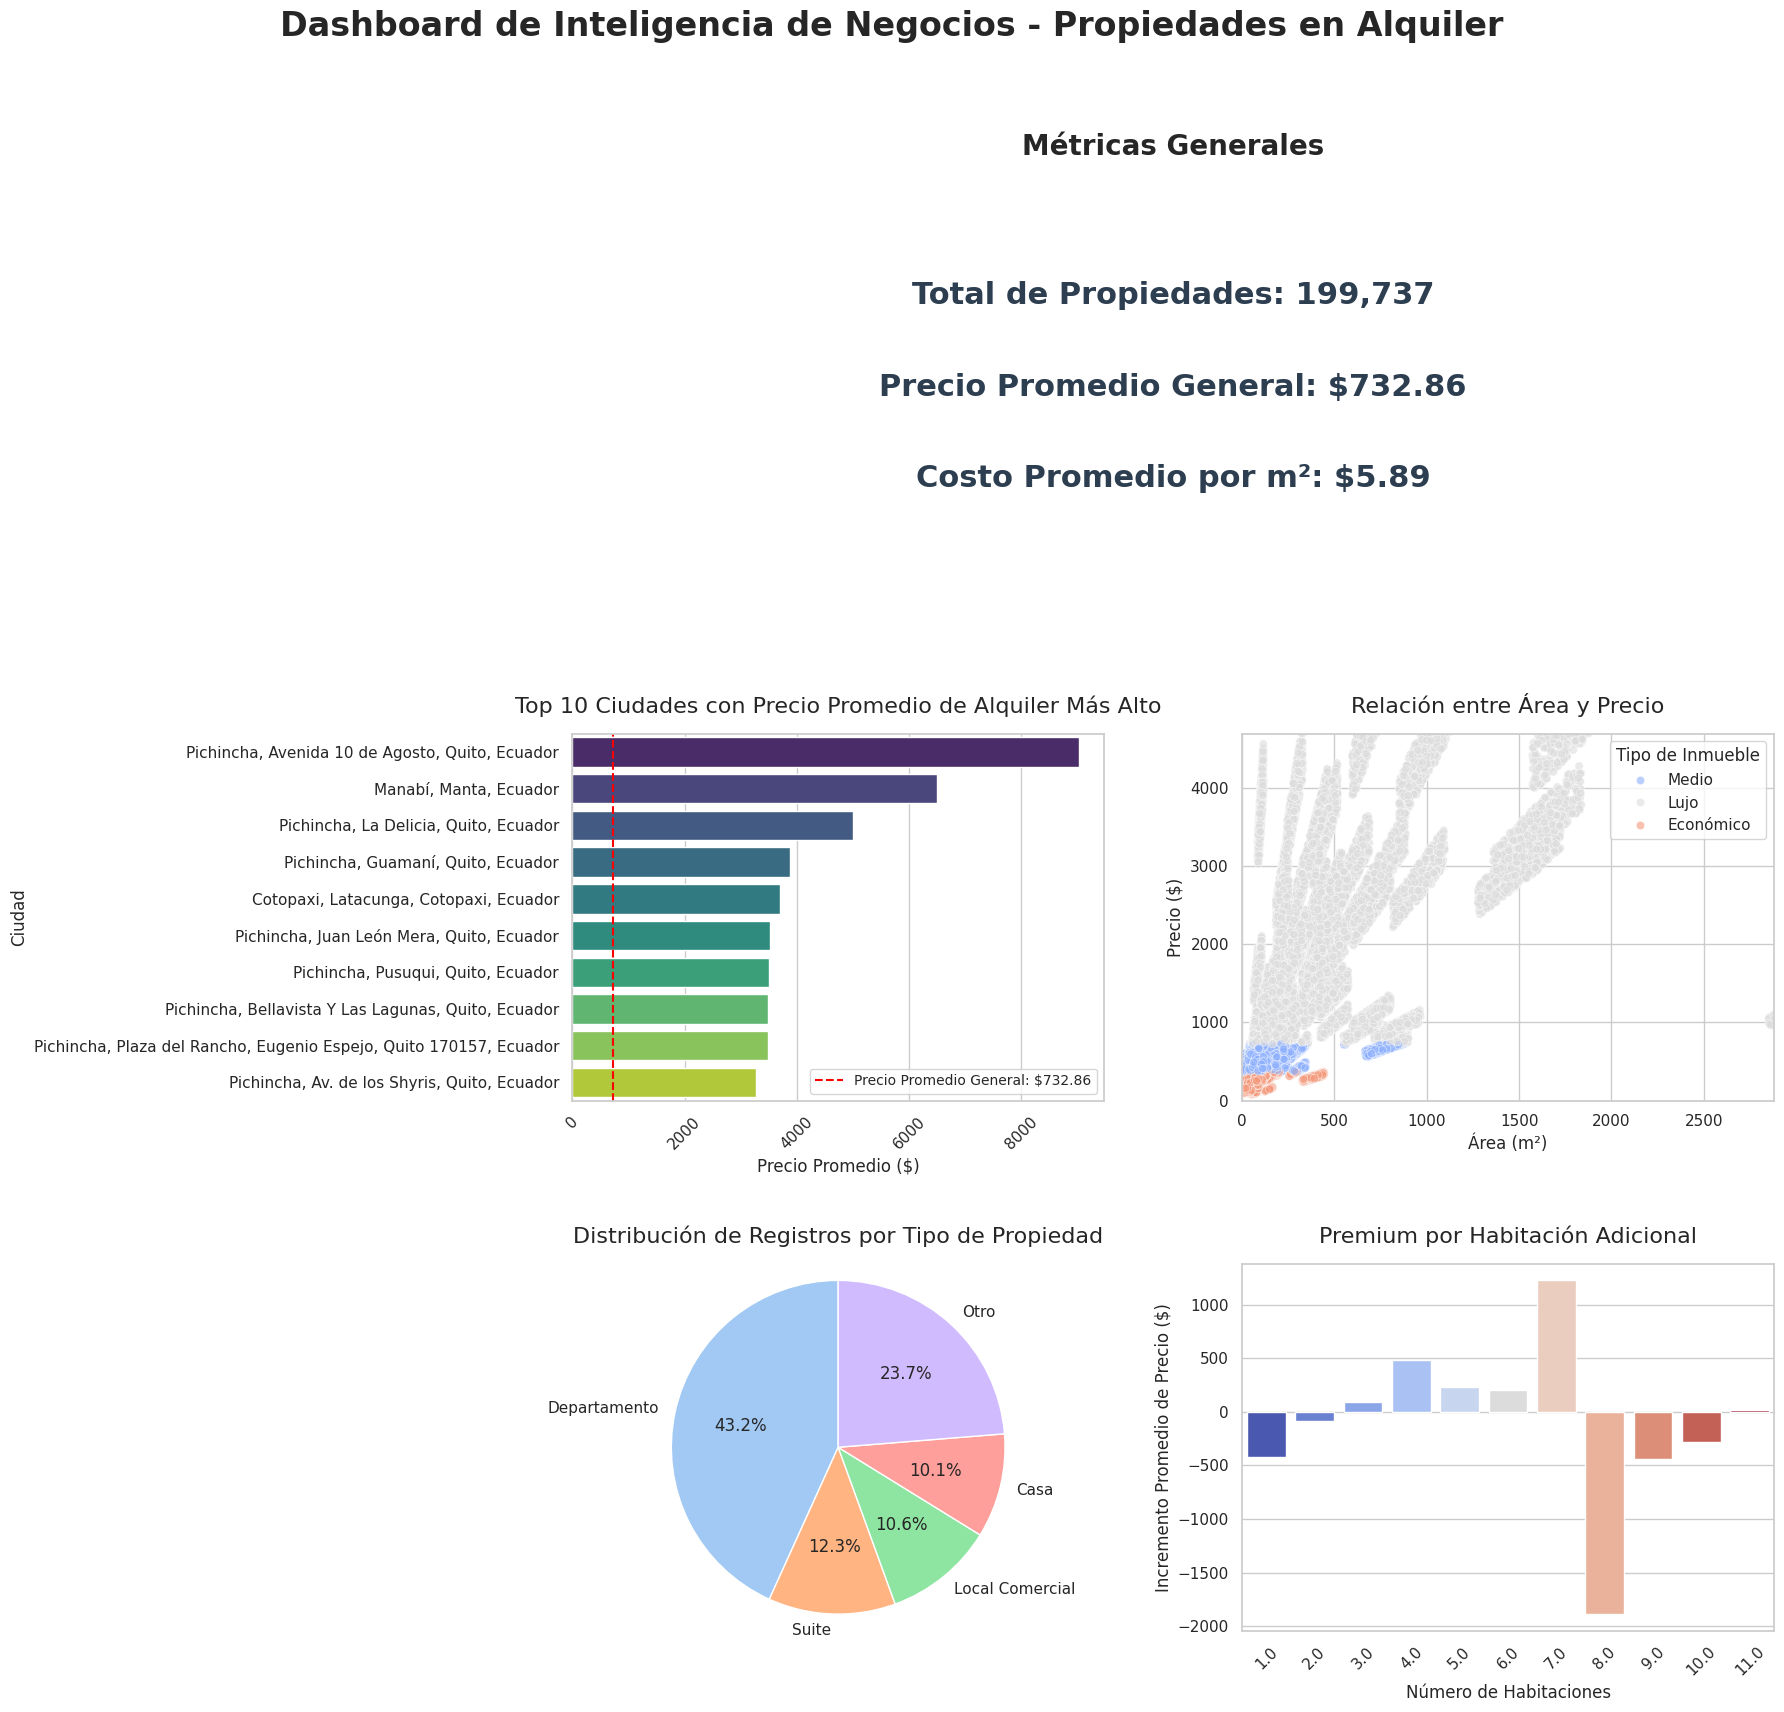

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a style for the plots
sns.set_style("whitegrid")

plt.figure(figsize=(15, 15)) # Further reduced figure size for more compactness
plt.suptitle('Dashboard de Inteligencia de Negocios - Propiedades en Alquiler', fontsize=22, fontweight='bold', y=0.98)

# 1. Total de propiedades (Text) and other key metrics in one row, spanning both columns
ax0 = plt.subplot(3, 2, (1, 2)) # Spans columns 1 and 2 of the first row
# Adjusted x-coordinate for text to be visually more centered by moving slightly left
ax0.text(0.48, 0.75, f"Total de Propiedades: {len(df):,}", ha='center', va='center', fontsize=22, color='#2C3E50', fontweight='bold', fontfamily='sans-serif')
ax0.text(0.48, 0.5, f"Precio Promedio General: ${precio_general:,.2f}", ha='center', va='center', fontsize=22, color='#2C3E50', fontweight='bold', fontfamily='sans-serif')
ax0.text(0.48, 0.25, f"Costo Promedio por m²: ${costo_promedio_m2:,.2f}", ha='center', va='center', fontsize=22, color='#2C3E50', fontweight='bold', fontfamily='sans-serif')
ax0.set_title('Métricas Generales', fontsize=20, pad=35, ha='center', fontweight='bold', fontfamily='sans-serif')
ax0.axis('off') # Hide axes for text display

# 2. Gráfico de barras de Precio promedio de alquiler (General y por Ciudad)
# Filter top N cities for readability
top_n_cities = 10
city_prices_display = precio_ciudad.sort_values(by='Precio Promedio', ascending=False).head(top_n_cities)

ax1 = plt.subplot(3, 2, 3) # Second row, first column
sns.barplot(x='Precio Promedio', y='Ciudad', data=city_prices_display, palette='viridis', ax=ax1, hue='Ciudad', legend=False)
ax1.axvline(precio_general, color='red', linestyle='--', label=f'Precio Promedio General: ${precio_general:,.2f}')
ax1.set_title('Top 10 Ciudades con Precio Promedio de Alquiler Más Alto', fontsize=16, pad=15)
ax1.set_xlabel('Precio Promedio ($)', fontsize=12)
ax1.set_ylabel('Ciudad', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='lower right', fontsize=10)

# 3. Gráfico de dispersión de la relación entre Área y Precio
ax2 = plt.subplot(3, 2, 4) # Second row, second column
sns.scatterplot(x='Area', y='Precio', data=df, alpha=0.6, hue='Tipo_de_Inmueble', palette='coolwarm', ax=ax2)
ax2.set_title('Relación entre Área y Precio', fontsize=16, pad=15)
ax2.set_xlabel('Área (m²)', fontsize=12)
ax2.set_ylabel('Precio ($)', fontsize=12)
# Limit axes to 99th percentile to remove extreme outliers for better visualization
ax2.set_xlim(left=0, right=df['Area'].quantile(0.99))
ax2.set_ylim(bottom=0, top=df['Precio'].quantile(0.99))
ax2.legend(title='Tipo de Inmueble')

# 4. Gráfico de pastel de conteo de registros por Tipo
# Filter for specific types mentioned in the prompt
specific_types = ['Casa', 'Departamento', 'Suite', 'Local Comercial']
distribucion_filtered = distribucion_tipo[distribucion_tipo['Tipo de Propiedad'].isin(specific_types)]

# Include 'Otro' category for remaining types if they exist
other_count = distribucion_tipo[~distribucion_tipo['Tipo de Propiedad'].isin(specific_types)]['Cantidad'].sum()
if other_count > 0:
    distribucion_filtered = pd.concat([
        distribucion_filtered,
        pd.DataFrame([{'Tipo de Propiedad': 'Otro', 'Cantidad': other_count}])
    ], ignore_index=True)

ax3 = plt.subplot(3, 2, 5) # Third row, first column
ax3.pie(distribucion_filtered['Cantidad'], labels=distribucion_filtered['Tipo de Propiedad'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel')[0:len(distribucion_filtered)])
ax3.set_title('Distribución de Registros por Tipo de Propiedad', fontsize=16, pad=15)
ax3.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# 5. Gráfico de Premium por Habitación Adicional
ax4 = plt.subplot(3, 2, 6) # Third row, second column
# Remove NaN from premium calculation for plotting
precio_habitaciones_plot = precio_habitaciones.dropna(subset=['Premium'])

sns.barplot(x='Habitaciones', y='Premium', data=precio_habitaciones_plot, palette='coolwarm', ax=ax4, hue='Habitaciones', legend=False)
ax4.set_title('Premium por Habitación Adicional', fontsize=16, pad=15)
ax4.set_xlabel('Número de Habitaciones', fontsize=12)
ax4.set_ylabel('Incremento Promedio de Precio ($)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=5, w_pad=5) # Increased h_pad and w_pad for more spacing
plt.show()